# Turkish Sign Language (TSL) Recognition — AUTSL Subset

This notebook builds a small isolated sign language recognition pipeline:

1. Download a subset of the AUTSL (Ankara University Turkish Sign Language) dataset (20 Turkish words).
2. Extract body/hand landmarks from each video using MediaPipe's Pose and Hand Landmarker tasks.
3. Train a baseline LSTM classifier.
4. Train an Attention-LSTM classifier.
5. Train a Spatial-Attention-LSTM classifier and compare the results.





## 0. Setup


In [ ]:
!pip install -q mediapipe opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.3 MB/s eta 0:00:00


Don't forget to restart


In [ ]:
import os
import re
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Mount Google Drive
Used to persist the dataset and outputs across sessions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/tid_dataset"
DATA_PATH = os.path.join(BASE_PATH, "data")
OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")

os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Data folder:", DATA_PATH)
print("Output folder:", OUTPUT_PATH)

Mounted at /content/drive
Data folder: /content/drive/MyDrive/tid_dataset/data
Output folder: /content/drive/MyDrive/tid_dataset/outputs


## Download the AUTSL dataset (from Kaggle)

This step is independent of what is already in DATA_PATH — Colab's local disk (where the raw AUTSL zip is extracted) is temporary and gets wiped every new session, even though DATA_PATH on Drive persists. So this cell always makes sure autsl_data exists locally, downloading it again
if the session was restarted. Requires a kaggle.json API token (reused every time)

In [ ]:
KAGGLE_JSON_PATH = os.path.join(BASE_PATH, "kaggle.json")

if os.path.exists(KAGGLE_JSON_PATH):
    print("Found saved Kaggle credentials in Drive.")
else:
    print("Please upload your kaggle.json file:")
    from google.colab import files
    files.upload()
    import shutil
    shutil.copy("kaggle.json", KAGGLE_JSON_PATH)
    print("Saved kaggle.json to Drive for future sessions.")

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
import shutil
shutil.copy(KAGGLE_JSON_PATH, os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

if not os.path.exists("autsl_data"):
    print("autsl_data/ not found locally, downloading...")
    !pip install -q kaggle
    !kaggle datasets download -d sttaseen/autsl
    !unzip -q autsl.zip -d autsl_data
    print("Downloaded and extracted.")
else:
    print("autsl_data/ already present in this session, skipping download.")

Found saved Kaggle credentials in Drive.
autsl_data/ not found locally, downloading...
Dataset URL: https://www.kaggle.com/datasets/sttaseen/autsl
License(s): unknown
100% 12.3G/12.3G [02:49<00:00, 77.9MB/s]

Downloaded and extracted.


In [ ]:
import pandas as pd

if not os.path.exists("SignList_ClassId_TR_EN.csv"):
    !wget -q -O SignList_ClassId_TR_EN.csv "https://huggingface.co/datasets/aipieces/AUTSL/resolve/main/SignList_ClassId_TR_EN.csv"

label_df = pd.read_csv("SignList_ClassId_TR_EN.csv")
train_labels = pd.read_csv("autsl_data/train_labels.csv", header=None, names=["video_id", "class_id"])
train_labels = train_labels.merge(label_df, left_on="class_id", right_on="ClassId", how="left")

print("Total training videos:", len(train_labels))

Total training videos: 28142


### Selecting words and copying videos

Every time it runs, it wipes DATA_PATH and recopies a fresh set of
videos using the settings below. That way, changing NUM_WORDS/ VIDEOS_PER_WORD_LIMIT and
re-running always produces a consistent dataset

In [ ]:
import random
import shutil

MIN_VIDEOS_PER_WORD = 40
VIDEOS_PER_WORD_LIMIT = 60
NUM_WORDS = 20

# Start from a clean folder every time, so changing the settings above never leaves stale videos.
if os.path.exists(DATA_PATH):
    shutil.rmtree(DATA_PATH)
os.makedirs(DATA_PATH, exist_ok=True)

video_counts = train_labels["TR"].value_counts()
eligible_words = video_counts[video_counts >= MIN_VIDEOS_PER_WORD].index.tolist()
print(f"Words with at least {MIN_VIDEOS_PER_WORD} videos available:", len(eligible_words))

random.seed(35)
selected_words = random.sample(eligible_words, NUM_WORDS)
print("Selected words:", selected_words)

SOURCE_FOLDER = "autsl_data/train"

for word in selected_words:
    target_folder = os.path.join(DATA_PATH, word)
    os.makedirs(target_folder, exist_ok=True)

    word_videos = train_labels[train_labels["TR"] == word]["video_id"].tolist()[:VIDEOS_PER_WORD_LIMIT]

    copied = 0
    for vid in word_videos:
        filename = f"{vid}_color.mp4"
        source_path = os.path.join(SOURCE_FOLDER, filename)
        if os.path.exists(source_path):
            shutil.copy(source_path, os.path.join(target_folder, filename))
            copied += 1

    print(f"{word}: {copied} videos copied")

print("Data is stored in Drive:", DATA_PATH)

Words with at least 40 videos available: 226
Selected words: ['agir', 'persembe', 'gomlek', 'yemek', 'hakli', 'calismak', 'doktor', 'hali', 'turkiye', 'nasil', 'cekic', 'baba', 'pencere', 'vergi', 'eldiven', 'hafif', 'kolonya', 'yildiz', 'yastik', 'misafir']
agir: 60 videos copied
persembe: 60 videos copied
gomlek: 60 videos copied
yemek: 60 videos copied
hakli: 60 videos copied
calismak: 60 videos copied
doktor: 60 videos copied
hali: 60 videos copied
turkiye: 60 videos copied
nasil: 60 videos copied
cekic: 60 videos copied
baba: 60 videos copied
pencere: 60 videos copied
vergi: 60 videos copied
eldiven: 60 videos copied
hafif: 60 videos copied
kolonya: 60 videos copied
yildiz: 60 videos copied
yastik: 60 videos copied
misafir: 60 videos copied
Data is stored in Drive: /content/drive/MyDrive/tid_dataset/data


## 1. Landmark Extraction

Each frame is represented as a 225-dimensional vector:

- **Pose** (33 points × x,y,z) = 99
- **Left hand** (21 points × x,y,z) = 63
- **Right hand** (21 points × x,y,z) = 63

Total = **225**.

If a hand or the pose is not detected in a frame, that part of the vector is filled with zeros so the
model never crashes on missing detections.

In [ ]:
!wget -q -O pose_landmarker.task "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"
!wget -q -O hand_landmarker.task "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
print("Model files downloaded.")

Model files downloaded.


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

FEATURE_DIM = 33 * 3 + 21 * 3 + 21 * 3  # 225

pose_options = mp_vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path="pose_landmarker.task"),
    running_mode=mp_vision.RunningMode.VIDEO,
)
hand_options = mp_vision.HandLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path="hand_landmarker.task"),
    running_mode=mp_vision.RunningMode.VIDEO,
    num_hands=2,
)


def extract_landmarks_from_video(video_path):
    """Extracts a per-frame landmark sequence from a video file.
    Returns an array of shape (num_frames, 225).
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    frames_landmarks = []
    frame_idx = 0

    with mp_vision.PoseLandmarker.create_from_options(pose_options) as pose_landmarker, \
         mp_vision.HandLandmarker.create_from_options(hand_options) as hand_landmarker:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            timestamp_ms = int((frame_idx / fps) * 1000)
            frame_idx += 1

            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)

            pose_result = pose_landmarker.detect_for_video(mp_image, timestamp_ms)
            hand_result = hand_landmarker.detect_for_video(mp_image, timestamp_ms)

            frame_vec = []

            # Pose (33 points)
            if pose_result.pose_landmarks:
                for lm in pose_result.pose_landmarks[0]:
                    frame_vec.extend([lm.x, lm.y, lm.z])
            else:
                frame_vec.extend([0.0] * (33 * 3))

            # Hands, split by handedness (21 points each)
            left_hand = [0.0] * (21 * 3)
            right_hand = [0.0] * (21 * 3)

            if hand_result.hand_landmarks:
                for hand_lms, handedness in zip(hand_result.hand_landmarks, hand_result.handedness):
                    label = handedness[0].category_name  # "Left" or "Right"
                    coords = []
                    for lm in hand_lms:
                        coords.extend([lm.x, lm.y, lm.z])
                    if label == "Left":
                        left_hand = coords
                    else:
                        right_hand = coords

            frame_vec.extend(left_hand)
            frame_vec.extend(right_hand)
            frames_landmarks.append(frame_vec)

    cap.release()

    if len(frames_landmarks) == 0:
        return np.zeros((1, FEATURE_DIM))

    return np.array(frames_landmarks, dtype=np.float32)


def normalize_sequence_length(seq, target_len=30):
    """Resamples a video's landmark sequence to a fixed number of frames.
    Longer sequences are subsampled at even intervals; shorter ones are zero-padded.
    """
    n = len(seq)
    if n == target_len:
        return seq
    elif n > target_len:
        idx = np.linspace(0, n - 1, target_len).astype(int)
        return seq[idx]
    else:
        pad = np.zeros((target_len - n, seq.shape[1]), dtype=np.float32)
        return np.vstack([seq, pad])


def get_signer_id(filename):
    """AUTSL filenames look like 'signer0_sample1_color.mp4'. Returns the signer number,
    or -1 if the filename doesn't match the expected pattern."""
    match = re.match(r"signer(\d+)_", filename)
    return int(match.group(1)) if match else -1


print("Landmark extraction functions are ready. Feature dimension:", FEATURE_DIM)

Landmark extraction functions are ready. Feature dimension: 225


## 2. Process the Whole Dataset

Walks through every class folder under DATA_PATH, extracts landmarks for every video, and saves the results to disk so this expensive step never has to be repeated.

Also extracts each video's signer ID from its filename (AUTSL's signerX_sampleY_color.mp4
convention), used later for a signer-independent train/val/test split.

In [ ]:
TARGET_LEN = 30  # number of frames each video is normalized to

X_list = []
y_list = []
signer_list = []

class_names = sorted(os.listdir(DATA_PATH))
print("Found classes:", class_names)

for cl in class_names:
    class_dir = os.path.join(DATA_PATH, cl)
    if not os.path.isdir(class_dir):
        continue

    video_files = sorted(f for f in os.listdir(class_dir) if f.lower().endswith((".mp4", ".avi", ".mov")))

    for video_name in tqdm(video_files, desc=f"Processing: {cl}"):
        video_path = os.path.join(class_dir, video_name)
        landmarks = extract_landmarks_from_video(video_path)
        landmarks = normalize_sequence_length(landmarks, target_len=TARGET_LEN)
        X_list.append(landmarks)
        y_list.append(cl)
        signer_list.append(get_signer_id(video_name))

X = np.array(X_list, dtype=np.float32)  # (N, 30, 225)
y_raw = np.array(y_list)
signers = np.array(signer_list)

print("\nTotal number of examples:", X.shape[0])
print("Input shape:", X.shape)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)
print("Classes:", list(label_encoder.classes_))

n_unparsed = int(np.sum(signers == -1))
if n_unparsed > 0:
    print(f"\nWarning: could not parse a signer ID for {n_unparsed} video(s); "
          "the split step below will fall back to a random split if this happens.")

np.save(os.path.join(OUTPUT_PATH, "X.npy"), X)
np.save(os.path.join(OUTPUT_PATH, "y.npy"), y)
np.save(os.path.join(OUTPUT_PATH, "classes.npy"), label_encoder.classes_)
np.save(os.path.join(OUTPUT_PATH, "signers.npy"), signers)
print("\nSaved to:", OUTPUT_PATH)

Found classes: ['agir', 'baba', 'calismak', 'cekic', 'doktor', 'eldiven', 'gomlek', 'hafif', 'hakli', 'hali', 'kolonya', 'misafir', 'nasil', 'pencere', 'persembe', 'turkiye', 'vergi', 'yastik', 'yemek', 'yildiz']


Processing: yildiz: 100%|██████████| 60/60 [05:31<00:00,  5.52s/it]



Total number of examples: 1200
Input shape: (1200, 30, 225)
Number of classes: 20
Classes: [np.str_('agir'), np.str_('baba'), np.str_('calismak'), np.str_('cekic'), np.str_('doktor'), np.str_('eldiven'), np.str_('gomlek'), np.str_('hafif'), np.str_('hakli'), np.str_('hali'), np.str_('kolonya'), np.str_('misafir'), np.str_('nasil'), np.str_('pencere'), np.str_('persembe'), np.str_('turkiye'), np.str_('vergi'), np.str_('yastik'), np.str_('yemek'), np.str_('yildiz')]

Saved to: /content/drive/MyDrive/tid_dataset/outputs


### Resume from saved arrays
If you reopen this notebook later, skip landmark extraction and just run this cell.

In [ ]:
X = np.load(os.path.join(OUTPUT_PATH, "X.npy"))
y = np.load(os.path.join(OUTPUT_PATH, "y.npy"))
class_names = np.load(os.path.join(OUTPUT_PATH, "classes.npy"))
signers = np.load(os.path.join(OUTPUT_PATH, "signers.npy"))
num_classes = len(class_names)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("num_classes:", num_classes)
print("Classes:", list(class_names))

X shape: (1200, 30, 225)
y shape: (1200,)
num_classes: 20
Classes: [np.str_('agir'), np.str_('baba'), np.str_('calismak'), np.str_('cekic'), np.str_('doktor'), np.str_('eldiven'), np.str_('gomlek'), np.str_('hafif'), np.str_('hakli'), np.str_('hali'), np.str_('kolonya'), np.str_('misafir'), np.str_('nasil'), np.str_('pencere'), np.str_('persembe'), np.str_('turkiye'), np.str_('vergi'), np.str_('yastik'), np.str_('yemek'), np.str_('yildiz')]


##Checking Class Balance



In [ ]:
import collections

class_counts = collections.Counter(class_names[label] for label in y)
print("Examples per class:")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls:12s}: {count}")


Examples per class:
  agir        : 60
  baba        : 60
  calismak    : 60
  cekic       : 60
  doktor      : 60
  eldiven     : 60
  gomlek      : 60
  hafif       : 60
  hakli       : 60
  hali        : 60
  kolonya     : 60
  misafir     : 60
  nasil       : 60
  pencere     : 60
  persembe    : 60
  turkiye     : 60
  vergi       : 60
  yastik      : 60
  yemek       : 60
  yildiz      : 60


## Motion Feature

In [ ]:
def add_motion_features(X):
    """
    X: (N, T, 225) — landmark coordinates
    Returns: (N, T, 450) — og coordinates + inter-frame velocity
    v of 1st frame = 0 (bcs theres no prev. frame)
    """
    velocity = np.zeros_like(X)
    velocity[:, 1:, :] = X[:, 1:, :] - X[:, :-1, :]
    X_with_motion = np.concatenate([X, velocity], axis=-1)  # (N, T, 450)
    return X_with_motion

X = add_motion_features(X)
print("Motion features added. New X shape:", X.shape)  # (N, 30, 450)

FEATURE_DIM = X.shape[-1]  # now 450
print("New FEATURE_DIM:", FEATURE_DIM)

Motion features added. New X shape: (1200, 30, 450)
New FEATURE_DIM: 450


## 3. Train / Validation / Test Split

A **signer-independent split** is used when possible: different signers end up in different sets,
so the model is evaluated on people it never saw during training ( a fairer test of whether it
learned the sign rather than the signer).

If signer IDs couldn't be parsed from filenames, this automatically falls  back to a random stratified split (and prints a warning).

In [ ]:
def make_split(X, y, signers, test_size=0.3, val_ratio=0.5, random_state=42):
    if np.any(signers == -1):
        print("Signer IDs unavailable for some samples — using a random stratified split.")
        print("(Not signer-independent; note this as a limitation in your report.)")
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y)
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=val_ratio, random_state=random_state, stratify=y_temp)
        return X_train, X_val, X_test, y_train, y_val, y_test

    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, temp_idx = next(gss1.split(X, y, groups=signers))

    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=random_state)
    val_idx, test_idx = next(gss2.split(X[temp_idx], y[temp_idx], groups=signers[temp_idx]))
    val_idx, test_idx = temp_idx[val_idx], temp_idx[test_idx]

    print("Signer-independent split used.")
    print("Train signers:", sorted(set(signers[train_idx])))
    print("Val signers:  ", sorted(set(signers[val_idx])))
    print("Test signers: ", sorted(set(signers[test_idx])))

    return X[train_idx], X[val_idx], X[test_idx], y[train_idx], y[val_idx], y[test_idx]


X_train, X_val, X_test, y_train, y_val, y_test = make_split(X, y, signers)
print("\nTrain:", X_train.shape[0], "| Val:", X_val.shape[0], "| Test:", X_test.shape[0])


class LandmarkDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 8  # small dataset (20 words) -> small batch size works better

train_loader = DataLoader(LandmarkDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(LandmarkDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(LandmarkDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

Signer-independent split used.
Train signers: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10)]
Val signers:   [np.int64(0), np.int64(12)]
Test signers:  [np.int64(7), np.int64(13)]

Train: 657 | Val: 297 | Test: 246


## 4. Baseline Model — LSTM

A simple but functional LSTM classifier. It looks at all 30 frames of a video but bases its
decision only on the **final hidden state** (the **summary** the LSTM has built up by the end of
the sequence.

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        outputs, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # final hidden state of the last layer: (batch, hidden_dim)
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out


HIDDEN_DIM = 64

model = LSTMClassifier(input_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM, num_classes=num_classes).to(device)
print(model)

LSTMClassifier(
  (lstm): LSTM(450, 64, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=20, bias=True)
)


##Training Loop for the Baseline Model

In [ ]:
torch.manual_seed(42)

def train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
          best_val_acc = val_acc
          best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"Best Val Acc: {best_val_acc:.4f} (weights restored to this checkpoint)")

    return history


history = train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3)

Epoch 1/50 | Train Loss: 3.0227 | Val Loss: 2.9868 | Val Acc: 0.0606
Epoch 5/50 | Train Loss: 2.6439 | Val Loss: 2.5846 | Val Acc: 0.1313
Epoch 10/50 | Train Loss: 2.2559 | Val Loss: 2.1958 | Val Acc: 0.2256
Epoch 15/50 | Train Loss: 1.9202 | Val Loss: 1.9102 | Val Acc: 0.2896
Epoch 20/50 | Train Loss: 1.8159 | Val Loss: 1.9104 | Val Acc: 0.2828
Epoch 25/50 | Train Loss: 1.5123 | Val Loss: 1.7320 | Val Acc: 0.3670
Epoch 30/50 | Train Loss: 1.3302 | Val Loss: 1.7105 | Val Acc: 0.3434
Epoch 35/50 | Train Loss: 1.5714 | Val Loss: 1.7327 | Val Acc: 0.4074
Epoch 40/50 | Train Loss: 1.2403 | Val Loss: 1.8792 | Val Acc: 0.3939
Epoch 45/50 | Train Loss: 0.9521 | Val Loss: 1.9885 | Val Acc: 0.3704
Epoch 50/50 | Train Loss: 0.8436 | Val Loss: 1.7919 | Val Acc: 0.4007
Best Val Acc: 0.4444 (weights restored to this checkpoint)


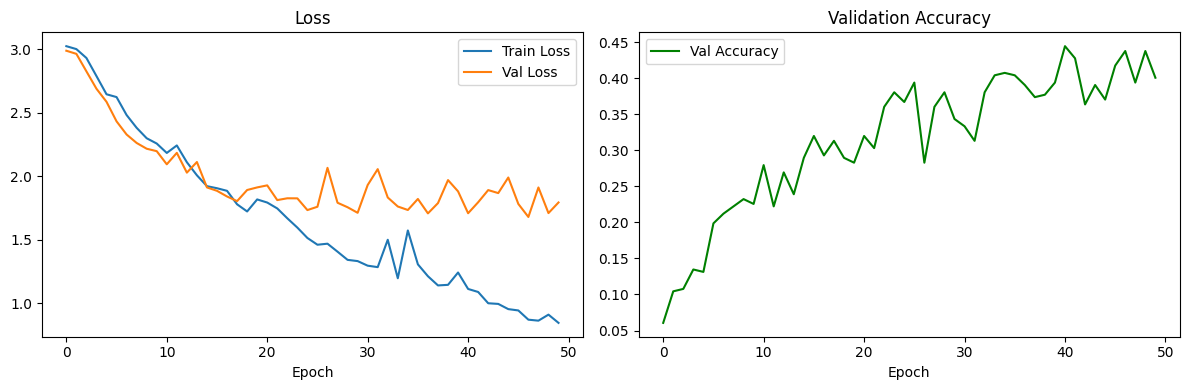

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Val Accuracy", color="green")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "training_curves.png"), dpi=150)
plt.show()

##Test Set Evaluation for the Baseline Model


Accuracy, F1-score, and a confusion matrix.

[Baseline LSTM] Test Accuracy: 0.5325
[Baseline LSTM] Test F1-score (macro): 0.4816

Classification report:
              precision    recall  f1-score   support

        agir       0.36      0.67      0.47        12
        baba       0.26      0.42      0.32        12
    calismak       0.75      0.75      0.75        12
       cekic       0.33      0.08      0.13        12
      doktor       0.69      0.92      0.79        12
     eldiven       0.63      1.00      0.77        12
      gomlek       0.75      0.75      0.75        12
       hafif       1.00      0.13      0.24        15
       hakli       0.55      0.73      0.63        15
        hali       0.00      0.00      0.00        12
     kolonya       0.69      0.92      0.79        12
     misafir       0.00      0.00      0.00        12
       nasil       0.60      0.25      0.35        12
     pencere       0.71      1.00      0.83        12
    persembe       0.13      0.17      0.15        12
     turkiye       0.44    

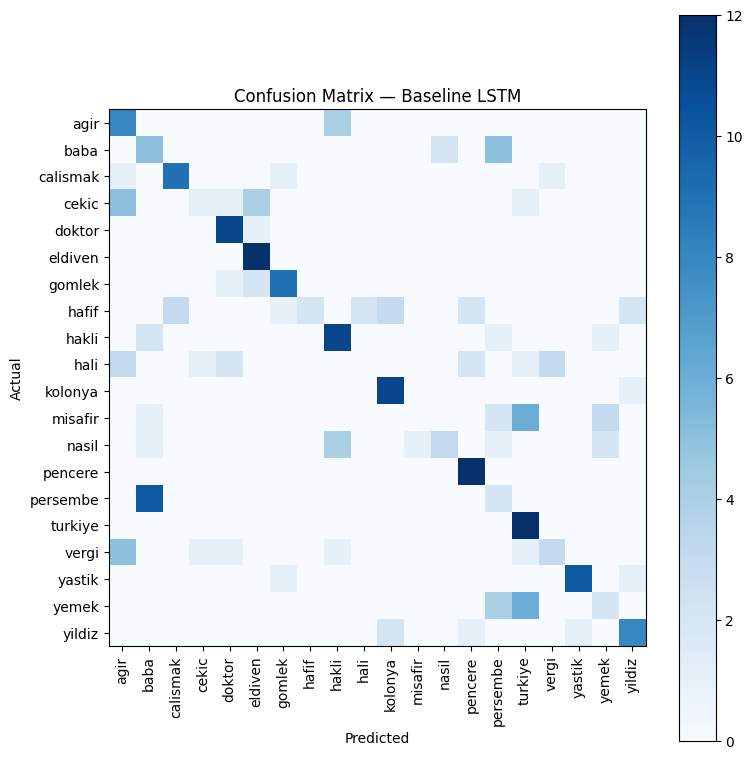

In [ ]:
def evaluate_model(model, test_loader, class_names, title="Baseline LSTM"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"[{title}] Test Accuracy: {acc:.4f}")
    print(f"[{title}] Test F1-score (macro): {f1:.4f}\n")
    print("Classification report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {title}")
    plt.colorbar(im)
    plt.tight_layout()
    safe_name = title.lower().replace(" ", "_")
    plt.savefig(os.path.join(OUTPUT_PATH, f"confusion_matrix_{safe_name}.png"), dpi=150)
    plt.show()

    return acc, f1


test_acc, test_f1 = evaluate_model(model, test_loader, class_names, title="Baseline LSTM")

In [ ]:
torch.save(model.state_dict(), os.path.join(OUTPUT_PATH, "baseline_lstm.pt"))
print("Baseline model saved.")

Baseline model saved.


---
## 5. Attention LSTM

Attention looks at every frame's hidden
state and **learns weights** for "**how important was this frame for recognizing the sign**".

In [ ]:
class AttentionLSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # Small network that assigns an importance score to each time step
        self.attention_fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        outputs, _ = self.lstm(x)  # outputs: (batch, seq_len, hidden_dim) -- ALL time steps

        attn_scores = self.attention_fc(outputs)          # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)  # normalize over time

        context = torch.sum(attn_weights * outputs, dim=1)  # weighted sum: (batch, hidden_dim)

        out = self.dropout(context)
        out = self.fc(out)
        return out, attn_weights  # weights returned for later visualization


attention_model = AttentionLSTMClassifier(input_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM, num_classes=num_classes).to(device)
print(attention_model)

AttentionLSTMClassifier(
  (lstm): LSTM(450, 64, batch_first=True)
  (attention_fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=20, bias=True)
)


##Training Loop for the Attention Model

In [ ]:
torch.manual_seed(42)

def train_attention_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs, _ = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}


        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


    model.load_state_dict(best_state)
    print(f"Best Val Acc: {best_val_acc:.4f} (weights restored to this checkpoint)")


    return history


attention_history = train_attention_model(attention_model, train_loader, val_loader, num_epochs=50, lr=1e-3)

torch.save(attention_model.state_dict(), os.path.join(OUTPUT_PATH, "attention_model.pt"))
print("Attention model saved.")

Epoch 1/50 | Train Loss: 3.0141 | Val Loss: 2.9763 | Val Acc: 0.0505
Epoch 5/50 | Train Loss: 2.3834 | Val Loss: 2.2328 | Val Acc: 0.2424
Epoch 10/50 | Train Loss: 1.8447 | Val Loss: 1.9303 | Val Acc: 0.3131
Epoch 15/50 | Train Loss: 1.4559 | Val Loss: 1.7546 | Val Acc: 0.3805
Epoch 20/50 | Train Loss: 1.2559 | Val Loss: 1.9112 | Val Acc: 0.3434
Epoch 25/50 | Train Loss: 1.1109 | Val Loss: 1.8248 | Val Acc: 0.4007
Epoch 30/50 | Train Loss: 0.8931 | Val Loss: 1.7847 | Val Acc: 0.4377
Epoch 35/50 | Train Loss: 0.7755 | Val Loss: 1.8853 | Val Acc: 0.3906
Epoch 40/50 | Train Loss: 0.7282 | Val Loss: 1.9616 | Val Acc: 0.4074
Epoch 45/50 | Train Loss: 0.7126 | Val Loss: 1.8415 | Val Acc: 0.4377
Epoch 50/50 | Train Loss: 0.6359 | Val Loss: 1.7274 | Val Acc: 0.4916
Best Val Acc: 0.4949 (weights restored to this checkpoint)
Attention model saved.


## Test Set Evaluation for the Attention Model


Accuracy, F1-score, confusion matrix, comparison with the baseline model.

[Attention LSTM] Test Accuracy: 0.6057
[Attention LSTM] Test F1-score (macro): 0.5937


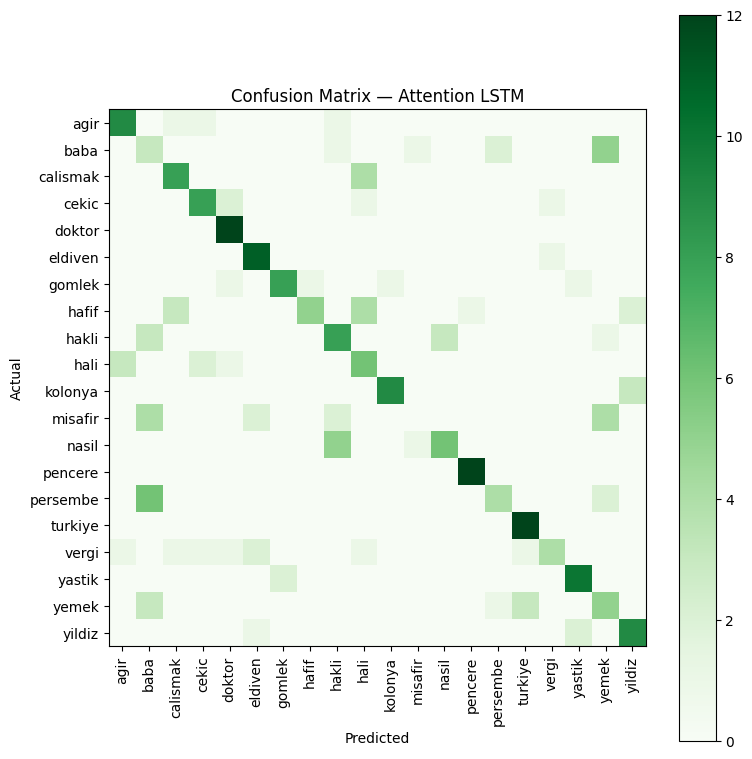


=== Comparison (for the 'Experiments' section of the report) ===
Baseline LSTM   -> Accuracy: 0.4878 | F1: 0.4462
Attention LSTM  -> Accuracy: 0.6057 | F1: 0.5937


In [ ]:
def evaluate_attention_model(model, test_loader, class_names, title="Attention LSTM"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs, _ = model(X_batch)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"[{title}] Test Accuracy: {acc:.4f}")
    print(f"[{title}] Test F1-score (macro): {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(cm, cmap="Greens")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {title}")
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, "confusion_matrix_attention.png"), dpi=150)
    plt.show()

    return acc, f1


attn_test_acc, attn_test_f1 = evaluate_attention_model(attention_model, test_loader, class_names)

print("\n=== Comparison (for the 'Experiments' section of the report) ===")
print(f"Baseline LSTM   -> Accuracy: {test_acc:.4f} | F1: {test_f1:.4f}")
print(f"Attention LSTM  -> Accuracy: {attn_test_acc:.4f} | F1: {attn_test_f1:.4f}")

##7. Ensemble

The Baseline and Attention models make different kinds of mistakes. By averaging their predicted
class probabilities (softmax outputs)  some of each other's errors can be corrected and give a small accuracy boost at no extra training cost.

In [ ]:
model.eval(); attention_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        out1 = model(X_batch)
        out2, _ = attention_model(X_batch)
        combined = torch.softmax(out1, dim=1) + torch.softmax(out2, dim=1)
        preds = combined.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print("Ensemble Accuracy:", accuracy_score(all_labels, all_preds))
print("Ensemble F1:", f1_score(all_labels, all_preds, average='macro'))

Ensemble Accuracy: 0.556910569105691
Ensemble F1: 0.5119298745661677


##8. Spatial Attention (Extension)
This extension adds a second, complementary attention mechanism that decides **which body part matters within each frame**: pose, left hand, or right hand. Each group is projected into its own small embedding,
scored, and combined with a softmax-weighted sum — the exact same score → softmax → weighted-sum
pattern as temporal attention, just applied across body-part groups instead of across time. The
fused per-frame representation is then fed into an LSTM, followed by the same temporal attention
as before.



In [ ]:
class SpatialAttentionLSTM(nn.Module):
    def __init__(self, feature_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()

        if feature_dim == 225:
            self.groups = {
                'pose':  list(range(0, 99)),
                'left':  list(range(99, 162)),
                'right': list(range(162, 225)),
            }
        elif feature_dim == 450:  # if motion features were added
            self.groups = {
                'pose':  list(range(0, 99))   + list(range(225, 324)),
                'left':  list(range(99, 162)) + list(range(324, 387)),
                'right': list(range(162, 225))+ list(range(387, 450)),
            }
        else:
            raise ValueError(f"Unexpected feature_dim: {feature_dim}")

        group_embed_dim = 32

        # Separate projection layer per group (pose/left/right each has its own W, b)
        self.group_proj = nn.ModuleDict({
            name: nn.Linear(len(idx), group_embed_dim) for name, idx in self.groups.items()
        })
        self.spatial_score = nn.Linear(group_embed_dim, 1)  # same score -> softmax pattern as attention_fc

        self.lstm = nn.LSTM(input_size=group_embed_dim, hidden_size=hidden_dim,
                             num_layers=1, batch_first=True)
        self.temporal_attn = nn.Linear(hidden_dim, 1)       # same temporal attention as AttentionLSTMClassifier

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, feature_dim)
        group_embeds, group_scores = [], []

        for name, idx in self.groups.items():
            idx_t = torch.tensor(idx, device=x.device)
            group_feat = x[:, :, idx_t]                              # (batch, seq_len, group_size)
            embed = torch.relu(self.group_proj[name](group_feat))    # (batch, seq_len, 32)
            score = self.spatial_score(embed)                        # (batch, seq_len, 1)
            group_embeds.append(embed)
            group_scores.append(score)

        group_embeds = torch.stack(group_embeds, dim=2)   # (batch, seq_len, 3, 32)  -- 3 = pose/left/right
        group_scores = torch.stack(group_scores, dim=2)   # (batch, seq_len, 3, 1)

        spatial_weights = torch.softmax(group_scores, dim=2)          # normalize across the 3 groups
        fused = torch.sum(spatial_weights * group_embeds, dim=2)      # (batch, seq_len, 32)

        outputs, _ = self.lstm(fused)                                  # (batch, seq_len, hidden_dim)

        t_scores = self.temporal_attn(outputs)
        t_weights = torch.softmax(t_scores, dim=1)
        context = torch.sum(t_weights * outputs, dim=1)                # (batch, hidden_dim)

        out = self.dropout(context)
        out = self.fc(out)
        return out, t_weights, spatial_weights

##Training Loop for the Spatial Attention Model

In [ ]:
torch.manual_seed(42)

def train_spatial_attention_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs, _, _ = model(X_batch)          # spatial model returns 3 values: out, t_weights, spatial_weights
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs, _, _ = model(X_batch)      # again 3 values here
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_state)
    print(f"Best Val Acc: {best_val_acc:.4f} (weights restored to this checkpoint)")

    return history


spatial_model = SpatialAttentionLSTM(feature_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM, num_classes=num_classes).to(device)
print(spatial_model)

spatial_history = train_spatial_attention_model(spatial_model, train_loader, val_loader, num_epochs=50, lr=1e-3)

torch.save(spatial_model.state_dict(), os.path.join(OUTPUT_PATH, "spatial_attention_model.pt"))
print("Spatial attention model saved.")


SpatialAttentionLSTM(
  (group_proj): ModuleDict(
    (pose): Linear(in_features=198, out_features=32, bias=True)
    (left): Linear(in_features=126, out_features=32, bias=True)
    (right): Linear(in_features=126, out_features=32, bias=True)
  )
  (spatial_score): Linear(in_features=32, out_features=1, bias=True)
  (lstm): LSTM(32, 64, batch_first=True)
  (temporal_attn): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=20, bias=True)
)
Epoch 1/50 | Train Loss: 3.0026 | Val Loss: 2.9952 | Val Acc: 0.0505
Epoch 5/50 | Train Loss: 2.6305 | Val Loss: 2.5376 | Val Acc: 0.1212
Epoch 10/50 | Train Loss: 2.3866 | Val Loss: 2.5065 | Val Acc: 0.1515
Epoch 15/50 | Train Loss: 2.1763 | Val Loss: 2.4863 | Val Acc: 0.1684
Epoch 20/50 | Train Loss: 2.0350 | Val Loss: 2.2769 | Val Acc: 0.2458
Epoch 25/50 | Train Loss: 1.8199 | Val Loss: 2.3670 | Val Acc: 0.2391
Epoch 30/50 | Train Loss: 1.5614 | Val Loss: 2.1139 

## Test Set Evaluation for the Spatial Attention Model


Accuracy, F1-score, confusion matrix, comparison with the other models.

[Spatial Attention LSTM] Test Accuracy: 0.3374
[Spatial Attention LSTM] Test F1-score (macro): 0.3013

Classification report:
              precision    recall  f1-score   support

        agir       0.80      0.33      0.47        12
        baba       0.00      0.00      0.00        12
    calismak       0.40      0.50      0.44        12
       cekic       0.40      0.17      0.24        12
      doktor       0.47      0.75      0.58        12
     eldiven       0.26      0.58      0.36        12
      gomlek       0.27      0.25      0.26        12
       hafif       0.00      0.00      0.00        15
       hakli       0.60      0.60      0.60        15
        hali       0.05      0.08      0.06        12
     kolonya       0.36      0.33      0.35        12
     misafir       0.22      0.17      0.19        12
       nasil       0.20      0.08      0.12        12
     pencere       1.00      1.00      1.00        12
    persembe       0.00      0.00      0.00        12
     turk

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


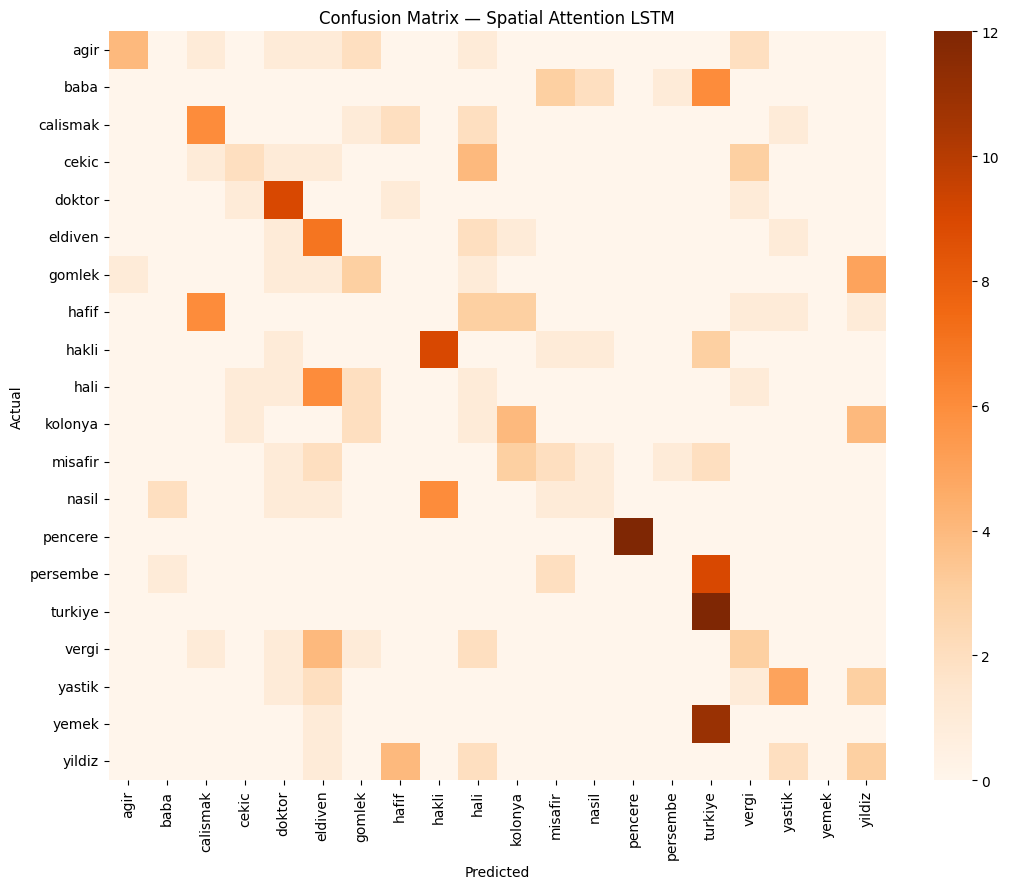


=== Comparison (for the report's 'Experiments' section) ===
Baseline LSTM          -> Accuracy: 0.5325 | F1: 0.4816


NameError: name 'attn_test_acc' is not defined

In [ ]:
import seaborn as sns

spatial_model.eval()  # important: must switch off dropout before evaluating
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs, _, _ = spatial_model(X_batch)     # spatial model returns 3 values
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

spatial_test_acc = accuracy_score(all_labels, all_preds)
spatial_test_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"[Spatial Attention LSTM] Test Accuracy: {spatial_test_acc:.4f}")
print(f"[Spatial Attention LSTM] Test F1-score (macro): {spatial_test_f1:.4f}")
print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix (same visual format as the Baseline/Attention plots above)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=False, cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Spatial Attention LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "confusion_matrix_spatial.png"), dpi=150)
plt.show()

print("\n=== Comparison (for the report's 'Experiments' section) ===")
print(f"Baseline LSTM          -> Accuracy: {test_acc:.4f} | F1: {test_f1:.4f}")
print(f"Attention LSTM         -> Accuracy: {attn_test_acc:.4f} | F1: {attn_test_f1:.4f}")
print(f"Spatial Attention LSTM -> Accuracy: {spatial_test_acc:.4f} | F1: {spatial_test_f1:.4f}")


##9.  Multi-Seed Robustness Check (Attention Model)


In [ ]:
import numpy as np

def evaluate_attention_on_test(m, test_loader):
    m.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _ = m(X_batch)          # attention model returns 2 values
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

seed_results = []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = AttentionLSTMClassifier(input_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM,
                                  num_classes=num_classes, dropout=0.5).to(device)
    train_attention_model(m, train_loader, val_loader, num_epochs=50, lr=1e-3)
    acc, f1 = evaluate_attention_on_test(m, test_loader)
    seed_results.append(acc)
    print(f"Seed {seed}: Test Acc = {acc:.4f}, Test F1 = {f1:.4f}")

print(f"\nMean Test Acc: {np.mean(seed_results):.4f} ± {np.std(seed_results):.4f}")

Epoch 1/50 | Train Loss: 3.0209 | Val Loss: 2.9786 | Val Acc: 0.0505
Epoch 5/50 | Train Loss: 2.5236 | Val Loss: 2.4198 | Val Acc: 0.1751
Epoch 10/50 | Train Loss: 1.9938 | Val Loss: 2.0345 | Val Acc: 0.2694
Epoch 15/50 | Train Loss: 1.5867 | Val Loss: 1.8301 | Val Acc: 0.3434
Epoch 20/50 | Train Loss: 1.3790 | Val Loss: 1.8431 | Val Acc: 0.3636
Epoch 25/50 | Train Loss: 1.1985 | Val Loss: 1.6409 | Val Acc: 0.4108
Epoch 30/50 | Train Loss: 1.2430 | Val Loss: 1.7202 | Val Acc: 0.3939
Epoch 35/50 | Train Loss: 0.9240 | Val Loss: 1.7134 | Val Acc: 0.4209
Epoch 40/50 | Train Loss: 0.9155 | Val Loss: 1.8302 | Val Acc: 0.4141
Epoch 45/50 | Train Loss: 0.7504 | Val Loss: 1.9781 | Val Acc: 0.4040
Epoch 50/50 | Train Loss: 0.8508 | Val Loss: 1.6986 | Val Acc: 0.4579
Best Val Acc: 0.4680 (weights restored to this checkpoint)
Seed 42: Test Acc = 0.4756, Test F1 = 0.4162
Epoch 1/50 | Train Loss: 3.0236 | Val Loss: 2.9772 | Val Acc: 0.1145
Epoch 5/50 | Train Loss: 2.5033 | Val Loss: 2.3919 | Val Ac

##9.  Multi-Seed Robustness Check (Baseline and Spatial Model)

In [ ]:
# --- Baseline LSTM: 3-seed check ---
def evaluate_baseline_on_test(m, test_loader):
    m.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = m(X_batch)               # baseline model returns 1 value
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

baseline_seed_results = []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = LSTMClassifier(input_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM,
                        num_classes=num_classes, dropout=0.5).to(device)
    train_model(m, train_loader, val_loader, num_epochs=50, lr=1e-3)
    acc, f1 = evaluate_baseline_on_test(m, test_loader)
    baseline_seed_results.append(acc)
    print(f"Seed {seed}: Test Acc = {acc:.4f}, Test F1 = {f1:.4f}")

print(f"\nBaseline Mean Test Acc: {np.mean(baseline_seed_results):.4f} ± {np.std(baseline_seed_results):.4f}")


# --- Spatial+Temporal Attention: 3-seed check ---
def evaluate_spatial_on_test(m, test_loader):
    m.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _, _ = m(X_batch)         # spatial model returns 3 values
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

spatial_seed_results = []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = SpatialAttentionLSTM(feature_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM,
                              num_classes=num_classes, dropout=0.5).to(device)
    train_spatial_attention_model(m, train_loader, val_loader, num_epochs=50, lr=1e-3)
    acc, f1 = evaluate_spatial_on_test(m, test_loader)
    spatial_seed_results.append(acc)
    print(f"Seed {seed}: Test Acc = {acc:.4f}, Test F1 = {f1:.4f}")

print(f"\nSpatial Mean Test Acc: {np.mean(spatial_seed_results):.4f} ± {np.std(spatial_seed_results):.4f}")

Epoch 1/50 | Train Loss: 3.0344 | Val Loss: 2.9902 | Val Acc: 0.0471
Epoch 5/50 | Train Loss: 2.9342 | Val Loss: 2.8230 | Val Acc: 0.1178
Epoch 10/50 | Train Loss: 2.4416 | Val Loss: 2.3561 | Val Acc: 0.2121
Epoch 15/50 | Train Loss: 2.2071 | Val Loss: 2.1825 | Val Acc: 0.2256
Epoch 20/50 | Train Loss: 1.8865 | Val Loss: 2.3084 | Val Acc: 0.1886
Epoch 25/50 | Train Loss: 1.6706 | Val Loss: 1.9591 | Val Acc: 0.2997
Epoch 30/50 | Train Loss: 1.5359 | Val Loss: 1.8740 | Val Acc: 0.3367
Epoch 35/50 | Train Loss: 1.4869 | Val Loss: 1.9185 | Val Acc: 0.3300
Epoch 40/50 | Train Loss: 1.1753 | Val Loss: 1.7871 | Val Acc: 0.3670
Epoch 45/50 | Train Loss: 1.0397 | Val Loss: 1.8479 | Val Acc: 0.3535
Epoch 50/50 | Train Loss: 1.0083 | Val Loss: 1.8825 | Val Acc: 0.3636
Best Val Acc: 0.4175 (weights restored to this checkpoint)
Seed 42: Test Acc = 0.4634, Test F1 = 0.4228
Epoch 1/50 | Train Loss: 3.0234 | Val Loss: 2.9679 | Val Acc: 0.1347
Epoch 5/50 | Train Loss: 2.6440 | Val Loss: 2.5279 | Val Ac

###10. Attention Weights Visualization

Shows which frames the attention model focused on for one correctly.

Selected sample index in batch: 0
Actual word: agir
Predicted word: agir


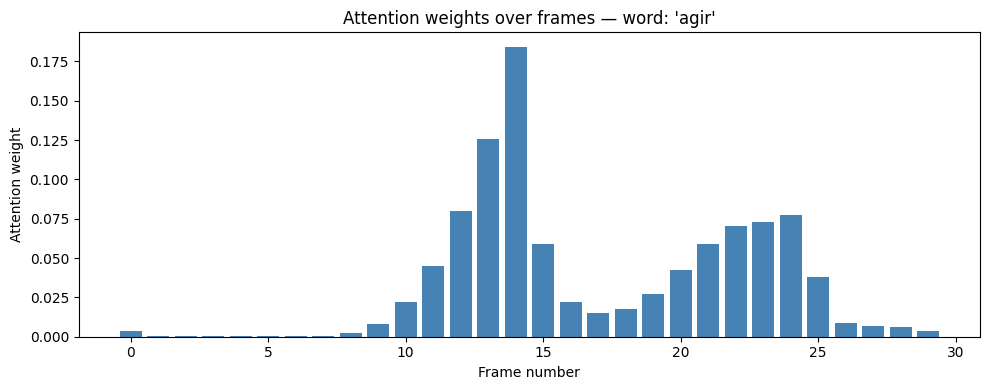

In [ ]:
attention_model.eval()

X_batch, y_batch = next(iter(test_loader))
X_batch_device = X_batch.to(device)

with torch.no_grad():
    outputs, attn_weights = attention_model(X_batch_device)
    preds = outputs.argmax(dim=1).cpu().numpy()

correct_idx = None
for i in range(len(preds)):
    if preds[i] == y_batch[i].item():
        correct_idx = i
        break

if correct_idx is not None:
    print("Selected sample index in batch:", correct_idx)
    print("Actual word:", class_names[y_batch[correct_idx].item()])
    print("Predicted word:", class_names[preds[correct_idx]])

    sample_weights = attn_weights[correct_idx].cpu().numpy().flatten()

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(sample_weights)), sample_weights, color="steelblue")
    plt.xlabel("Frame number")
    plt.ylabel("Attention weight")
    plt.title(f"Attention weights over frames — word: '{class_names[y_batch[correct_idx].item()]}'")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, "attention_weights_example.png"), dpi=150)
    plt.show()
else:
    print("No correct prediction in this batch — re-run the cell to sample a different batch.")